In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [4]:
#Load the csv file
df=pd.read_csv('/content/House Price Prediction Dataset.csv')


In [5]:
df.head()#view the structure

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [7]:
#handling missing values check
df.isnull().sum()
print(df.isnull().sum())

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [8]:
df.duplicated().sum()
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0
0


In [9]:
#fill mode for object data type
df['Location'].fillna(df['Location'].mode()[0])

df['Condition'].fillna(df['Condition'].mode()[0])

df['Garage'].fillna(df['Garage'].mode()[0])


,Garage
0,No
1,No
2,No
3,Yes
4,Yes
...,...
1995,No
1996,Yes
1997,No
1998,Yes


In [10]:
#encoding
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['Location']=le.fit_transform(df['Location'])
df['Condition']=le.fit_transform(df['Condition'])
df['Garage']=le.fit_transform(df['Garage'])



#or using one hot encoding

#df_encoded = pd.get_dummies(df, columns=['Location', 'Condition', 'Garage'], drop_first=True)

In [11]:
df['Location']=df['Location'].astype(int)
df['Condition']=df['Condition'].astype(int)
df['Garage']=df['Garage'].astype(int)

In [12]:
print(df.dtypes)#data check to ensure variables are in correct mathematical modeling

Id           int64
Area         int64
Bedrooms     int64
Bathrooms    int64
Floors       int64
YearBuilt    int64
Location     int64
Condition    int64
Garage       int64
Price        int64
dtype: object


In [13]:
df=df.astype(int)
print(df.dtypes)

Id           int64
Area         int64
Bedrooms     int64
Bathrooms    int64
Floors       int64
YearBuilt    int64
Location     int64
Condition    int64
Garage       int64
Price        int64
dtype: object


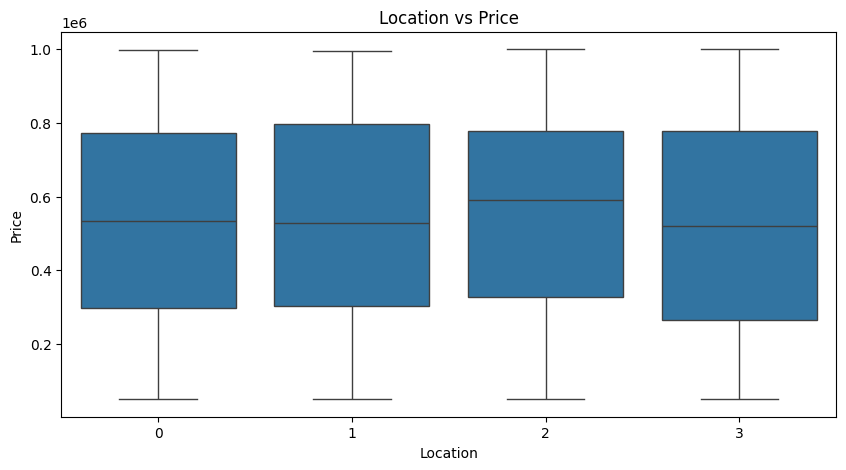

'This helps to see if certain locations have higher median prices'

In [14]:
#compaing catagories
#to find the outliers using box plot
#using seabron library(The trend discovery)
#visualization (the trend discovery)
#plot:Location vs price
plt.figure(figsize=(10,5))
sns.boxplot(x='Location',y='Price',data=df)
plt.xlabel('Location')
plt.ylabel('Price')
plt.title('Location vs Price')
plt.show()
'''This helps to see if certain locations have higher median prices'''

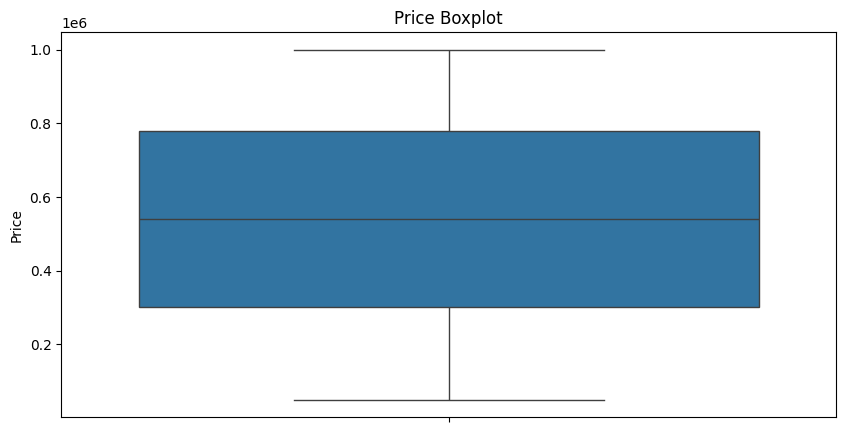

In [15]:
#Basic boxplot for the price (which is the target here)
#this helps to see any outliers in the price column
plt.figure(figsize=(10,5))
sns.boxplot(df['Price'])
plt.title('Price Boxplot')
plt.show()

In [16]:
print("---------Lowest salaries---------")
print(df["Price"].sort_values().head(5))

print("---------Highest salaries---------")
print(df["Price"].sort_values().tail(5))

---------Lowest salaries---------
1167    50005
836     50064
1728    51082
1592    51845
1463    52024
Name: Price, dtype: int64
---------Highest salaries---------
241     997719
1552    998084
1006    998128
1787    999453
1004    999656
Name: Price, dtype: int64


In [17]:
#divide the target variable and independent variable
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
X=df.drop('Price',axis=1)#Independent variable
y=df['Price']#dependent variable

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 9)
(400, 9)
(1600,)
(400,)


In [18]:
'''Training the Model ---
# Initialize and fit Linear Regression[cite: 1]'''
model = LinearRegression()
model

LinearRegression()

In [19]:
model.fit(X_train, y_train)

LinearRegression()

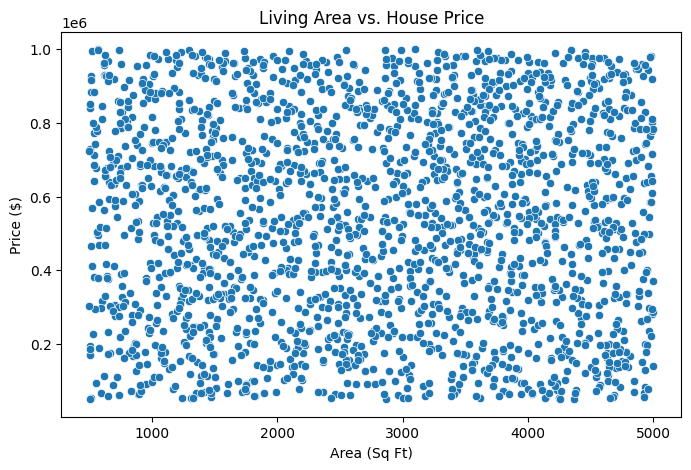

In [34]:
#This is for visualization b/w living area and price
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Area', y='Price', data=df)
#or plt.scatter(x='Area',y='Price',data=df)
plt.title('Living Area vs. House Price')
plt.xlabel('Area (Sq Ft)')
plt.ylabel('Price ($)')
plt.show()

In [22]:
print("\n model performance metrices")
y_pred=model.predict(X_test)

#check the result
print(f"Mean Absolute Error:{mean_absolute_error(y_pred,y_test)}")
print(f"Mean Squared Error:{mean_squared_error(y_pred,y_test)}")
print(f"Roor Mean Squared Error:{np.sqrt(mean_squared_error(y_pred,y_test))}")
print(f"R2 Score:{r2_score(y_test,y_pred)}")



 model performance metrices
Mean Absolute Error:244003.46389812755
Mean Squared Error:78663273949.43434
Roor Mean Squared Error:280469.73802789196
R2 Score:-0.011111291082151142


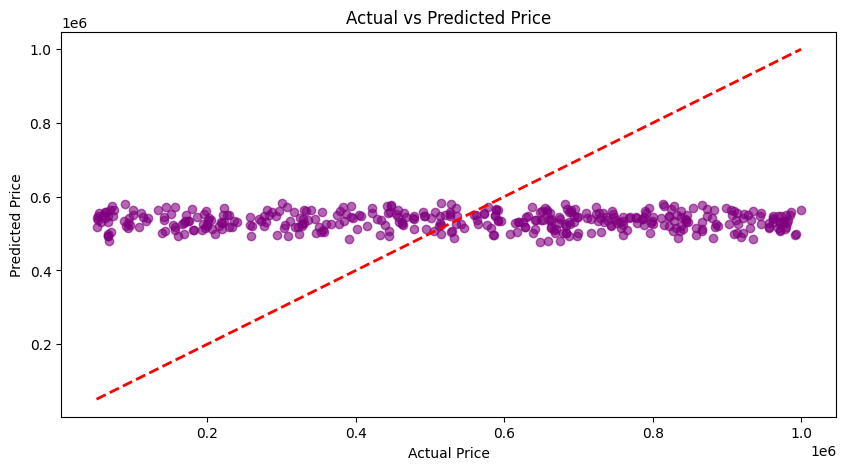

In [24]:
#for visualization of actual price and predicted price
#Visulising
plt.figure(figsize=(10,5))
plt.scatter(y_test,y_pred,color='purple',alpha=0.6)#alpha for visibility
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',lw=2)#to reduce biased condition
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

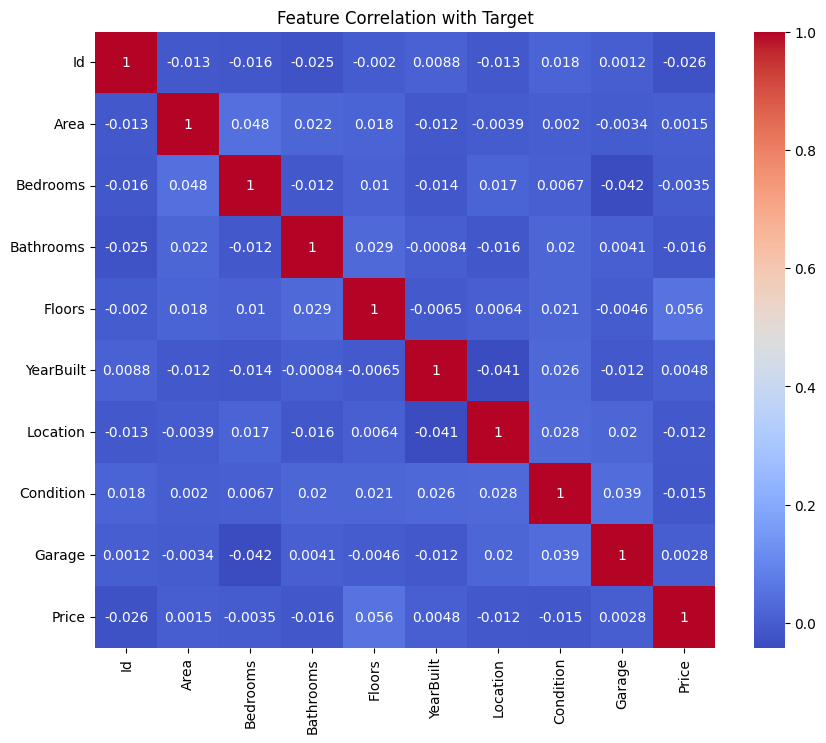

In [28]:
#corrolation heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation with Target')
plt.show()


In [30]:
# Real-time dummy data based on House Price features
new_house_dict = {
    'Area': [2500],
    'Bedrooms': [3],
    'Bathrooms': [2],
    'Floors': [2],
    'YearBuilt': [2010]
}
# Create a DataFrame with all columns from X_train, initialized to 0
# This ensures encoded categorical columns (like Location) are present
new_data = pd.DataFrame(0, index=[0], columns=X_train.columns)

#Fill the known numerical values

for col, val in new_house_dict.items():
    if col in new_data.columns:
        new_data[col] = val[0]

# Set specific categorical columns (e.g., set Location to Suburban)
if 'Location_Suburban' in new_data.columns:
    new_data['Location_Suburban'] = 1

else:
  pass



# Ask the model for a prediction
prediction = model.predict(new_data)

print("------------ Realtime House Price Prediction -----------")
print(f"Predicted Price: ${prediction[0]:,.2f}")





------------ Realtime House Price Prediction -----------
Predicted Price: $565,089.36
